In [1]:
from pathlib import Path
from typing import Any
import numpy as np
from dataclasses import dataclass
import datetime

from my_types import Quat, ScalarBatch, Vec3Batch, QuatBatch
from io_csv import load_gyro_base, load_ref, load_acc, load_mag, load_grav_ref, load_acc_lin_ref, read_best_from_log
from pipelines import generate_m_ref_world_h_unit, integrate_gyro_acc_mag
from evaluation import calc_angle_err, print_err_status, score_angle_err
from evaluation import save_err_csv, plot_err_from_csv, find_estimated_vec3_sign
from evaluation import save_estimated_vec3_csv, evaluate_estimated_vec3_autosign, calc_vec3_direction_angle_err
from resample import find_stable_start_idx, cut_sample
from autotune import auto_setup_imu_frame, quasi_static_detector, build_segment, suggest_fixed_gate_sigma
from optuna_exp_4 import exp_4_1, exp_4_2, exp_4_3, exp_4_4, exp_4_5, exp_4_6
from Tee import Tee

SIGMA_FLOOR: float = 1e-3
EPS: float = 1e-9

In [2]:
sample_1: str = "data01_21:08_oct_07_2025_5min"
sample_2: str = "data02_21:23_oct_07_2025_9min"
sample_3: str = "data03_21:41_oct_07_2025_13min"
sample_4: str = "data04_18:52_oct_08_2025_96min"

sample: str = sample_1

root: Path = Path.cwd().parent
run_dir: Path = root / "data" / sample

ori_path: Path = run_dir / "Orientation.csv"
gyro_path: Path = run_dir / "Gyroscope.csv"
acc_path: Path = run_dir / "AccelerometerUncalibrated.csv"
mag_path: Path = run_dir / "Magnetometer.csv"
grav_path: Path = run_dir / "Gravity.csv"
acc_lin_path: Path = run_dir / "Accelerometer.csv"

for p in [ori_path, gyro_path, acc_path, mag_path, grav_path, acc_lin_path]:
        if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")

out_dir: Path = root / "output" / sample / "exp_4"
out_dir.mkdir(parents=True, exist_ok=True)

path_log: Path = out_dir / "04_exp4_log.txt"
path_err_1: Path = out_dir / "04_exp4-1_angle_err.csv"
path_err_2: Path = out_dir / "04_exp4-2_angle_err.csv"
path_err_3: Path = out_dir / "04_exp4-3_angle_err.csv"
path_err_4: Path = out_dir / "04_exp4-4_angle_err.csv"
path_err_5: Path = out_dir / "04_exp4-5_angle_err.csv"
path_err_6: Path = out_dir / "04_exp4-6_angle_err.csv"

path_plot: Path = out_dir / "04_exp4_plot.png"

path_est_grav: Path = out_dir / "04_exp4_grav_est.csv"
path_est_acc: Path = out_dir / "04_exp4_acc_lin_est.csv"

for p in [path_log, path_err_1, path_err_2, path_err_3, path_err_4, path_err_5, path_err_6,
          path_plot, path_est_grav, path_est_acc]:
        if p.is_file():
                p.unlink()

In [3]:
with Tee(path_log):
        t_src_gyro, w_src_gyro, dt, t_new, w_avg_gyro = load_gyro_base(gyro_path)

        q_ref_interp = load_ref(ori_path, t_new)
        q_ref_interp /= np.linalg.norm(q_ref_interp, axis=1, keepdims=True)

        g_ref_interp = load_grav_ref(grav_path, t_new)
        a_lin_ref_interp = load_acc_lin_ref(acc_lin_path, t_new)

        idx_cut: int = find_stable_start_idx(dt, w_avg_gyro, q_ref_interp,
                                             sample_window=1000, threshold=0.5, sample_hz=100,
                                             consecutive=3, min_cut_second=10, max_cut_second=30)
        t_cut: int = idx_cut / 100
        a_src_interp = load_acc(acc_path, t_new)
        m_src_interp = load_mag(mag_path, t_new)
        [dt, t_new, w_avg_gyro, q_ref_interp,
         a_src_interp, m_src_interp,
         g_ref_interp, a_lin_ref_interp] = cut_sample(idx_cut,
                                                      [dt, t_new, w_avg_gyro, q_ref_interp,
                                                       a_src_interp, m_src_interp,
                                                       g_ref_interp, a_lin_ref_interp])



[START] 2026-03-24 23:14:11.532

[INFO] Stabilization detected too early (< min_cut), applying min_cut=10s policy

[END] 2026-03-24 23:14:12.006




In [4]:
with Tee(path_log):
        q0: Quat = q_ref_interp[0].copy()
        g0: float = 9.80665
        a_src_interp, g_world_unit = auto_setup_imu_frame(q_ref_interp, w_avg_gyro, dt,
                                                          g0, a_src_interp)
        print("")

        m0: float = np.median(np.linalg.norm(m_src_interp, axis=1))
        m_ref_world_h_unit = generate_m_ref_world_h_unit(g0, g_world_unit, 5000,
                                                         q_ref_interp, a_src_interp, m_src_interp)
        
        best_quasi_static = quasi_static_detector(w_avg_gyro, a_src_interp, dt, g0,
                                                  w_thr=4, a_thr=4,
                                                  min_duration_s=0.5, smooth_win=5)
        print("")

        gyro_gate_sigma, acc_gate_sigma, mag_gate_sigma = suggest_fixed_gate_sigma(
                                                                w_avg_gyro, a_src_interp, m_src_interp,
                                                                g0, m0,
                                                                p_gyro=90, p_acc=90, p_mag=90, sigma_floor=SIGMA_FLOOR,
                                                                best_quasi_static=best_quasi_static)

        print("")
        seg_1 = build_segment(len(dt), 100, 5, 5, 15, 3)
        print("[seg_1] head: 5, tail: 5, stride: 15, win: 3")
        seg_2 = build_segment(len(dt), 100, 10, 10, 15, 5)
        print("[seg_2] head: 10, tail: 10, stride: 15, win: 5")
        seg_3: list[tuple[int, int]] = None
        if len(dt) > 30*60*100:
                seg_3 = build_segment(len(dt), 100,30, 30, 20, 10)
                print("[seg_3] head: 30, tail: 30, stride: 20, win: 10")



[START] 2026-03-24 23:14:12.020

Detected accel unit in [m/s²]


Selected g_world_unit: [ 0  0 -1]

Best quasi static(start, end, length):  (2523, 3540, 1017)

Suggested gyro_sigma:  0.44791971689543864
Suggested acc_sigma:  2.908568806018301
Suggested mag_sigma:  6.850455808768257

[seg_1] head: 5, tail: 5, stride: 15, win: 3
[seg_2] head: 10, tail: 10, stride: 15, win: 5

[END] 2026-03-24 23:14:12.790




In [5]:
def runner_exp4(*,
               q0: Quat,
               dt: ScalarBatch,
               w: Vec3Batch,
               a: Vec3Batch,
               m: Vec3Batch,
               K: float,
               mag_gain: float,
               acc_gate_sigma: float = np.inf,
               gyro_gate_sigma: float = np.inf,
               mag_gate_sigma: float = np.inf,
               mag_err_sigma: float = np.inf,
               **kwargs: Any):
        q_est, g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag  = integrate_gyro_acc_mag(
                                                                q0, w, dt,
                                                                K, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, mag_gain,
                                                                acc_gate_sigma, gyro_gate_sigma,
                                                                mag_gate_sigma, mag_err_sigma,
                                                                a, m)
        return q_est, (g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag)

In [6]:
@dataclass
class Data:
        exp: str
        q_est: QuatBatch
        g_body_est: Vec3Batch
        a_lin_est: Vec3Batch
        angle_err: ScalarBatch

In [7]:
def print_time_now(flag: str) -> None:
        now: str = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
        print(flag, ": ", now)

In [8]:
# exp 4-1: Gyro+Acc+Mag without any gating

with Tee(path_log):
        data_exp1_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-1-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                best_tau_1, best_K_1, best_mag_gain_1 = exp_4_1(seg=seg,
                                                                dt=dt, q_ref=q_ref_interp,
                                                                w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                                                                best_quasi_static=best_quasi_static,
                                                                tau_candidate=(0.1, 4),
                                                                mag_gain_candidate=(0.01, 10),
                                                                runner_func=runner_exp4,
                                                                n_trials=20)

                print("\n[chosen value]")
                print("tau=", best_tau_1, ", K=", best_K_1)
                print("mag_gain=", best_mag_gain_1)
                print("acc_gate_sigma=inf")
                print("gyro_gate_sigma=inf")
                print("mag_gate_sigma=inf")
                print("mag_err_sigma=inf\n")

                [q_est_1, g_body_est_1, a_lin_est_1,
                weight_acc_1, weight_gyro_1, weight_mag_1] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_1, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_1,
                                                                np.inf, np.inf,
                                                                np.inf, np.inf,
                                                                a_src_interp, m_src_interp)

                angle_err_1: ScalarBatch = calc_angle_err(q_est_1, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag", angle_err_1)

                data_exp1_map[exp] = Data("[exp4-1] ", q_est_1, g_body_est_1, a_lin_est_1, angle_err_1)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:14:12,848] A new study created in memory with name: no-name-7bca150d-0f1f-4165-a0ce-c433e98919a5




[START] 2026-03-24 23:14:12.847

start :  2026-03-24 23:14:12.847


[I 2026-03-24 23:14:14,678] Trial 0 finished with value: 0.11495053943096172 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062}. Best is trial 0 with value: 0.11495053943096172.
[I 2026-03-24 23:14:16,423] Trial 1 finished with value: 0.07062535177886094 and parameters: {'tau': 2.95477637306448, 'mag_gain': 5.990598257128395}. Best is trial 1 with value: 0.07062535177886094.
[I 2026-03-24 23:14:18,158] Trial 2 finished with value: 0.09790608009917869 and parameters: {'tau': 0.7084726977255024, 'mag_gain': 1.5683852581586646}. Best is trial 1 with value: 0.07062535177886094.
[I 2026-03-24 23:14:19,848] Trial 3 finished with value: 0.1890233853288618 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603}. Best is trial 1 with value: 0.07062535177886094.
[I 2026-03-24 23:14:21,674] Trial 4 finished with value: 0.08655949630752258 and parameters: {'tau': 2.4443485457985146, 'mag_gain': 7.0836450521824945}. Best is trial 1 with value: 0.0706253517


[chosen value]
tau= 3.932469060126895 , K= 0.0025426212244773093
mag_gain= 3.5771776662400905
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=inf



[I 2026-03-24 23:14:53,541] A new study created in memory with name: no-name-29ecd12e-e15f-4717-84d8-d50de87580ba


[exp 4-1-1] Gyro+Acc+Mag angle error in rad — min/max/mean/p90
0.002818835027033219 0.7172417482362367 0.042172969711376365 0.08175313998327868

[exp 4-1-1] Gyro+Acc+Mag angle error in deg — min/max/mean/p90
0.16150735019264875 41.09492506452112 2.416333173994919 4.68410988298409

end :  2026-03-24 23:14:53.541



start :  2026-03-24 23:14:53.541


[I 2026-03-24 23:14:56,455] Trial 0 finished with value: 0.13236882729301694 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062}. Best is trial 0 with value: 0.13236882729301694.
[I 2026-03-24 23:14:59,300] Trial 1 finished with value: 0.08010250186169252 and parameters: {'tau': 2.95477637306448, 'mag_gain': 5.990598257128395}. Best is trial 1 with value: 0.08010250186169252.
[I 2026-03-24 23:15:02,157] Trial 2 finished with value: 0.11260784172166452 and parameters: {'tau': 0.7084726977255024, 'mag_gain': 1.5683852581586646}. Best is trial 1 with value: 0.08010250186169252.
[I 2026-03-24 23:15:05,012] Trial 3 finished with value: 0.2075159613334148 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603}. Best is trial 1 with value: 0.08010250186169252.
[I 2026-03-24 23:15:07,850] Trial 4 finished with value: 0.09907664186823936 and parameters: {'tau': 2.4443485457985146, 'mag_gain': 7.0836450521824945}. Best is trial 1 with value: 0.0801025018


[chosen value]
tau= 3.932469060126895 , K= 0.0025426212244773093
mag_gain= 3.5771776662400905
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=inf

[exp 4-1-2] Gyro+Acc+Mag angle error in rad — min/max/mean/p90
0.002818835027033219 0.7172417482362367 0.042172969711376365 0.08175313998327868

[exp 4-1-2] Gyro+Acc+Mag angle error in deg — min/max/mean/p90
0.16150735019264875 41.09492506452112 2.416333173994919 4.68410988298409

end :  2026-03-24 23:15:57.864




[END] 2026-03-24 23:15:57.864




In [9]:
# exp 4-2: Gyro+Acc+Mag+Gating(Mag innov)

with Tee(path_log):
        data_exp2_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-2-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                [best_tau_2, best_K_2, best_mag_gain_2,
                best_mag_err_sigma_2] = exp_4_2(seg=seg,
                                                dt=dt, q_ref=q_ref_interp,
                                                w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                                                best_quasi_static=best_quasi_static,
                                                tau_candidate=(best_tau_1 * 0.9, best_tau_1 * 1.1),
                                                mag_gain_candidate=(best_mag_gain_1 * 0.7, best_mag_gain_1 * 1.3),
                                                mag_err_sigma_candidate=(0.01, 2),
                                                runner_func=runner_exp4,
                                                n_trials=20)

                print("\n[chosen value]")
                print("tau=", best_tau_2, ", K=", best_K_2)
                print("mag_gain=", best_mag_gain_2)
                print("acc_gate_sigma=inf")
                print("gyro_gate_sigma=inf")
                print("mag_gate_sigma=inf")
                print(f"mag_err_sigma={best_mag_err_sigma_2:.7f}\n")

                [q_est_2, g_body_est_2, a_lin_est_2,
                weight_acc_2, weight_gyro_2, weight_mag_2] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_2, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_2,
                                                                np.inf, np.inf,
                                                                np.inf, best_mag_err_sigma_2,
                                                                a_src_interp, m_src_interp)        
                angle_err_2: ScalarBatch = calc_angle_err(q_est_2, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag+Gating(Mag_innov)", angle_err_2)

                data_exp2_map[exp] = Data("[exp4-2] ", q_est_2, g_body_est_2, a_lin_est_2, angle_err_2)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:15:57,878] A new study created in memory with name: no-name-6c0d23fa-2cd6-4047-9d1e-535feda2764b




[START] 2026-03-24 23:15:57.877

start :  2026-03-24 23:15:57.877


[I 2026-03-24 23:15:59,610] Trial 0 finished with value: 0.047914130770332915 and parameters: {'tau': 3.833795639942906, 'mag_gain': 4.5445487566867575, 'mag_err_sigma': 1.4666679442046962}. Best is trial 0 with value: 0.047914130770332915.
[I 2026-03-24 23:16:01,274] Trial 1 finished with value: 0.042569447260343916 and parameters: {'tau': 4.010063347451668, 'mag_gain': 2.8388882040327594, 'mag_err_sigma': 0.3204290954690433}. Best is trial 1 with value: 0.042569447260343916.
[I 2026-03-24 23:16:03,000] Trial 2 finished with value: 0.04945583677101471 and parameters: {'tau': 3.5849045556645764, 'mag_gain': 4.363103944585674, 'mag_err_sigma': 1.2062188733689856}. Best is trial 1 with value: 0.042569447260343916.
[I 2026-03-24 23:16:04,688] Trial 3 finished with value: 0.04412477506305081 and parameters: {'tau': 4.096116855015654, 'mag_gain': 2.548205002327538, 'mag_err_sigma': 1.9401206058023688}. Best is trial 1 with value: 0.042569447260343916.
[I 2026-03-24 23:16:06,439] Trial 4 fin


[chosen value]
tau= 4.312433686162575 , K= 0.0023185931714062844
mag_gain= 3.5863784326810215
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=1.7999687



[I 2026-03-24 23:16:39,022] A new study created in memory with name: no-name-a164e014-87df-4a58-b48c-e76c519e836a


[exp 4-2-1] Gyro+Acc+Mag+Gating(Mag_innov) angle error in rad — min/max/mean/p90
0.0028076995829799255 0.6989043582864635 0.04130586062209385 0.07945992702475674

[exp 4-2-1] Gyro+Acc+Mag+Gating(Mag_innov) angle error in deg — min/max/mean/p90
0.160869336245391 40.044270013113504 2.3666514828015988 4.552718458936074

end :  2026-03-24 23:16:39.021



start :  2026-03-24 23:16:39.021


[I 2026-03-24 23:16:41,781] Trial 0 finished with value: 0.052237181991839896 and parameters: {'tau': 3.833795639942906, 'mag_gain': 4.5445487566867575, 'mag_err_sigma': 1.4666679442046962}. Best is trial 0 with value: 0.052237181991839896.
[I 2026-03-24 23:16:44,681] Trial 1 finished with value: 0.042742163704194425 and parameters: {'tau': 4.010063347451668, 'mag_gain': 2.8388882040327594, 'mag_err_sigma': 0.3204290954690433}. Best is trial 1 with value: 0.042742163704194425.
[I 2026-03-24 23:16:47,413] Trial 2 finished with value: 0.05418734368757689 and parameters: {'tau': 3.5849045556645764, 'mag_gain': 4.363103944585674, 'mag_err_sigma': 1.2062188733689856}. Best is trial 1 with value: 0.042742163704194425.
[I 2026-03-24 23:16:50,202] Trial 3 finished with value: 0.04499238002217536 and parameters: {'tau': 4.096116855015654, 'mag_gain': 2.548205002327538, 'mag_err_sigma': 1.9401206058023688}. Best is trial 1 with value: 0.042742163704194425.
[I 2026-03-24 23:16:52,935] Trial 4 fin


[chosen value]
tau= 4.324743961186654 , K= 0.0023119933541997347
mag_gain= 3.3883234350286653
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=0.7612136

[exp 4-2-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in rad — min/max/mean/p90
0.0028060746198260754 0.6459638822521032 0.0414352367068872 0.08010108897878507

[exp 4-2-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in deg — min/max/mean/p90
0.16077623271481112 37.01100417093118 2.3740641864301844 4.589454332886258

end :  2026-03-24 23:17:42.277




[END] 2026-03-24 23:17:42.277




In [10]:
# exp 4-3: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — fixed sigma

with Tee(path_log):
        data_exp3_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-3-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                [best_tau_3, best_K_3, best_mag_gain_3,
                best_acc_sigma_3, best_gyro_sigma_3, best_mag_sigma_3] = exp_4_3(
                                                                        seg=seg,
                                                                        dt=dt, q_ref=q_ref_interp,
                                                                        w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                                                                        best_quasi_static=best_quasi_static,
                                                                        tau_candidate=(best_tau_2 * 0.9, best_tau_2 * 1.1),
                                                                        mag_gain_candidate=(best_mag_gain_2 * 0.7, best_mag_gain_2 * 1.3),
                                                                        acc_gate_sigma_candidate=(0.01*acc_gate_sigma, 10*acc_gate_sigma),
                                                                        gyro_gate_sigma_candidate=(0.1*gyro_gate_sigma, 10*gyro_gate_sigma),
                                                                        mag_gate_sigma_candidate=(0.01*mag_gate_sigma, 10*mag_gate_sigma),
                                                                        runner_func=runner_exp4,
                                                                        n_trials=30)

                print("\n[chosen value]")
                print("tau=", best_tau_3, ", K=", best_K_3)
                print("mag_gain=", best_mag_gain_3)
                print(f"acc_gate_sigma={best_acc_sigma_3:.7f}")
                print(f"gyro_gate_sigma={best_gyro_sigma_3:.7f}")
                print(f"mag_gate_sigma={best_mag_sigma_3:.7f}")
                print("mag_err_sigma=inf\n")

                [q_est_3, g_body_est_3, a_lin_est_3,
                weight_acc_3, weight_gyro_3, weight_mag_3] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_3, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_3,
                                                                best_acc_sigma_3, best_gyro_sigma_3,
                                                                best_mag_sigma_3, np.inf,
                                                                a_src_interp, m_src_interp)        
                angle_err_3: ScalarBatch = calc_angle_err(q_est_3, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm)", angle_err_3)

                data_exp3_map[exp] = Data("[exp4-3] ", q_est_3, g_body_est_3, a_lin_est_3, angle_err_3)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:17:42,293] A new study created in memory with name: no-name-d1977321-9c87-4635-9f2b-fedf674d67a6




[START] 2026-03-24 23:17:42.292

start :  2026-03-24 23:17:42.292


[I 2026-03-24 23:17:44,388] Trial 0 finished with value: 0.03703063736284985 and parameters: {'tau': 4.216227588509441, 'mag_gain': 4.304622943175511, 'acc_gate_sigma': 21.298342594076995, 'gyro_gate_sigma': 2.699486265399576, 'mag_gate_sigma': 10.745804587020885}. Best is trial 0 with value: 0.03703063736284985.
[I 2026-03-24 23:17:46,440] Trial 1 finished with value: 0.04387888966913484 and parameters: {'tau': 4.027196837028429, 'mag_gain': 2.489910043100441, 'acc_gate_sigma': 25.197221540060372, 'gyro_gate_sigma': 2.710379503917546, 'mag_gate_sigma': 48.52619739497609}. Best is trial 0 with value: 0.03703063736284985.
[I 2026-03-24 23:17:48,421] Trial 2 finished with value: 0.03768621969608815 and parameters: {'tau': 3.9100740985479585, 'mag_gain': 4.343647373687469, 'acc_gate_sigma': 24.217040499397907, 'gyro_gate_sigma': 0.9863896276638863, 'mag_gate_sigma': 12.511887746889654}. Best is trial 0 with value: 0.03703063736284985.
[I 2026-03-24 23:17:50,366] Trial 3 finished with valu


[chosen value]
tau= 4.756666899378352 , K= 0.002102055811010377
mag_gain= 3.846368915623853
acc_gate_sigma=9.9262628
gyro_gate_sigma=0.2901186
mag_gate_sigma=44.4812203
mag_err_sigma=inf



[I 2026-03-24 23:18:51,136] A new study created in memory with name: no-name-e684aa3f-d137-4d74-a138-cf82fb729059


[exp 4-3-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in rad — min/max/mean/p90
0.0020093365570454944 0.655451638793824 0.03703012581309122 0.05096400471693658

[exp 4-3-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in deg — min/max/mean/p90
0.11512650434005461 37.55461257781941 2.121669923928573 2.9200223773652856

end :  2026-03-24 23:18:51.135



start :  2026-03-24 23:18:51.135


[I 2026-03-24 23:18:54,420] Trial 0 finished with value: 0.03920903224249464 and parameters: {'tau': 4.216227588509441, 'mag_gain': 4.304622943175511, 'acc_gate_sigma': 21.298342594076995, 'gyro_gate_sigma': 2.699486265399576, 'mag_gate_sigma': 10.745804587020885}. Best is trial 0 with value: 0.03920903224249464.
[I 2026-03-24 23:18:57,723] Trial 1 finished with value: 0.04500103343127929 and parameters: {'tau': 4.027196837028429, 'mag_gain': 2.489910043100441, 'acc_gate_sigma': 25.197221540060372, 'gyro_gate_sigma': 2.710379503917546, 'mag_gate_sigma': 48.52619739497609}. Best is trial 0 with value: 0.03920903224249464.
[I 2026-03-24 23:19:01,044] Trial 2 finished with value: 0.04006722903190741 and parameters: {'tau': 3.9100740985479585, 'mag_gain': 4.343647373687469, 'acc_gate_sigma': 24.217040499397907, 'gyro_gate_sigma': 0.9863896276638863, 'mag_gate_sigma': 12.511887746889654}. Best is trial 0 with value: 0.03920903224249464.
[I 2026-03-24 23:19:04,307] Trial 3 finished with valu


[chosen value]
tau= 4.667684021939419 , K= 0.0021421285695179715
mag_gain= 3.6743687405123153
acc_gate_sigma=5.7291508
gyro_gate_sigma=0.4576878
mag_gate_sigma=39.1623427
mag_err_sigma=inf

[exp 4-3-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in rad — min/max/mean/p90
0.0007536155275271733 0.6100054306376016 0.036088372773354735 0.05379003003914591

[exp 4-3-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in deg — min/max/mean/p90
0.043178989102832147 34.95073665559485 2.067711449408056 3.081941701124979

end :  2026-03-24 23:20:39.430




[END] 2026-03-24 23:20:39.430




In [11]:
# exp 4-4: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — fixed sigma

with Tee(path_log):
        data_exp4_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-4-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                [best_tau_4, best_K_4, best_mag_gain_4,
                best_acc_sigma_4, best_gyro_sigma_4, best_mag_sigma_4,
                best_mag_err_sigma_4] = exp_4_4(seg=seg,
                                                dt=dt, q_ref=q_ref_interp,
                                                w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                                                best_quasi_static=best_quasi_static,
                                                tau_candidate=(best_tau_3 * 0.9, best_tau_3 * 1.1),
                                                mag_gain_candidate=(best_mag_gain_3 * 0.7, best_mag_gain_3 * 1.3),
                                                acc_gate_sigma_candidate=(best_acc_sigma_3 * 0.7, best_acc_sigma_3 * 1.3),
                                                gyro_gate_sigma_candidate=(best_gyro_sigma_3 * 0.7, best_gyro_sigma_3 * 1.3),
                                                mag_gate_sigma_candidate=(best_mag_sigma_3 * 0.7, best_mag_sigma_3 * 1.3),
                                                mag_err_sigma_candidate=(best_mag_err_sigma_2 * 0.5, best_mag_err_sigma_2 * 1.5),
                                                runner_func=runner_exp4,
                                                n_trials=20)

                print("\n[chosen value]")
                print("tau=", best_tau_4, ", K=", best_K_4)
                print("mag_gain=", best_mag_gain_4)
                print(f"acc_gate_sigma={best_acc_sigma_4:.7f}")
                print(f"gyro_gate_sigma={best_gyro_sigma_4:.7f}")
                print(f"mag_gate_sigma={best_mag_sigma_4:.7f}")
                print(f"mag_err_sigma={best_mag_err_sigma_4:.7f}\n")

                [q_est_4, g_body_est_4, a_lin_est_4,
                weight_acc_4, weight_gyro_4, weight_mag_4] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_4, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_4,
                                                                best_acc_sigma_4, best_gyro_sigma_4,
                                                                best_mag_sigma_4, best_mag_err_sigma_4,
                                                                a_src_interp, m_src_interp)        
                angle_err_4: ScalarBatch = calc_angle_err(q_est_4, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov)", angle_err_4)

                data_exp4_map[exp] = Data("[exp4-4] ", q_est_4, g_body_est_4, a_lin_est_4, angle_err_4)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:20:39,449] A new study created in memory with name: no-name-0ff73d1b-464c-4993-84af-fe38027de56f




[START] 2026-03-24 23:20:39.448

start :  2026-03-24 23:20:39.448


[I 2026-03-24 23:20:41,545] Trial 0 finished with value: 0.038260784756837966 and parameters: {'tau': 4.5505626054093025, 'mag_gain': 4.668023075536887, 'acc_gate_sigma': 6.526627726090897, 'gyro_gate_sigma': 0.48478067559535487, 'mag_gate_sigma': 31.079673198598975, 'mag_err_sigma': 0.4993519687189114}. Best is trial 0 with value: 0.038260784756837966.
[I 2026-03-24 23:20:43,518] Trial 1 finished with value: 0.039219597305145265 and parameters: {'tau': 4.255138809436284, 'mag_gain': 4.481648450646337, 'acc_gate_sigma': 6.076732652727095, 'gyro_gate_sigma': 0.5148271733686572, 'mag_gate_sigma': 27.89732212873752, 'mag_err_sigma': 1.118915411275438}. Best is trial 0 with value: 0.038260784756837966.
[I 2026-03-24 23:20:45,629] Trial 2 finished with value: 0.039556498746181036 and parameters: {'tau': 4.9780314624745134, 'mag_gain': 3.040185432757286, 'acc_gate_sigma': 4.635427125175853, 'gyro_gate_sigma': 0.3707466676804637, 'mag_gate_sigma': 34.56254331274514, 'mag_err_sigma': 0.7800585


[chosen value]
tau= 5.016312670696481 , K= 0.001993252804054321
mag_gain= 4.367920821449954
acc_gate_sigma=5.0794965
gyro_gate_sigma=0.3945917
mag_gate_sigma=27.5380465
mag_err_sigma=0.8856901



[I 2026-03-24 23:21:31,091] A new study created in memory with name: no-name-d3a5cea9-019b-45ac-946a-68a4272d96d4


[exp 4-4-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in rad — min/max/mean/p90
0.0006888292569035345 0.5534559532416731 0.033902277492087594 0.048926046078887606

[exp 4-4-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in deg — min/max/mean/p90
0.03946700922570526 31.7106902671377 1.9424574161779844 2.80325594858285

end :  2026-03-24 23:21:31.090



start :  2026-03-24 23:21:31.090


[I 2026-03-24 23:21:34,683] Trial 0 finished with value: 0.039480757923576026 and parameters: {'tau': 4.5505626054093025, 'mag_gain': 4.668023075536887, 'acc_gate_sigma': 6.526627726090897, 'gyro_gate_sigma': 0.48478067559535487, 'mag_gate_sigma': 31.079673198598975, 'mag_err_sigma': 0.4993519687189114}. Best is trial 0 with value: 0.039480757923576026.
[I 2026-03-24 23:21:38,054] Trial 1 finished with value: 0.04060341577765911 and parameters: {'tau': 4.255138809436284, 'mag_gain': 4.481648450646337, 'acc_gate_sigma': 6.076732652727095, 'gyro_gate_sigma': 0.5148271733686572, 'mag_gate_sigma': 27.89732212873752, 'mag_err_sigma': 1.118915411275438}. Best is trial 0 with value: 0.039480757923576026.
[I 2026-03-24 23:21:41,519] Trial 2 finished with value: 0.041341760443430985 and parameters: {'tau': 4.9780314624745134, 'mag_gain': 3.040185432757286, 'acc_gate_sigma': 4.635427125175853, 'gyro_gate_sigma': 0.3707466676804637, 'mag_gate_sigma': 34.56254331274514, 'mag_err_sigma': 0.78005856


[chosen value]
tau= 5.007891116670216 , K= 0.0019966047711371254
mag_gain= 4.148098120776027
acc_gate_sigma=5.1120395
gyro_gate_sigma=0.3595636
mag_gate_sigma=37.0785850
mag_err_sigma=0.8695816

[exp 4-4-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in rad — min/max/mean/p90
0.0006503528769452465 0.6221986265349649 0.03458455384894321 0.04781733703074702

[exp 4-4-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in deg — min/max/mean/p90
0.03726247504315361 35.64935531929 1.981548971887373 2.7397315994164275

end :  2026-03-24 23:22:50.119




[END] 2026-03-24 23:22:50.120




In [12]:
# exp 4-5: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — time-varying sigma

with Tee(path_log):
        data_exp5_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-5-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                [best_tau_5, best_K_5, best_mag_gain_5,
                best_p_5, best_win_s_5, best_update_ratio_5, best_ema_alpha_5,
                timevarying_acc_sigma_5, timevarying_gyro_sigma_5, timevarying_mag_sigma_5
                ] = exp_4_5(seg=seg,
                        dt=dt, q_ref=q_ref_interp,
                        g0=g0, sigma_floor=SIGMA_FLOOR,
                        w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                        best_quasi_static=best_quasi_static,
                        tau_candidate=(best_tau_4 * 0.9, best_tau_4 * 1.1),
                        mag_gain_candidate=(best_mag_gain_4 * 0.7, best_mag_gain_4 * 1.3),
                        p_candidate=(50, 80),
                        win_s_candidate=(5, 10),
                        update_ratio_candidate=(0.1, 0.5),
                        ema_candidate=(0.02, 0.2),
                        runner_func=runner_exp4,
                        n_trials=40)

                print("\n[chosen value]")
                print("tau=", best_tau_5, ", K=", best_K_5)
                print("mag_gain=", best_mag_gain_5)
                print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
                print("mag_err_sigma=inf\n")

                [q_est_5, g_body_est_5, a_lin_est_5,
                weight_acc_5, weight_gyro_5, weight_mag_5] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_5, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_5,
                                                                timevarying_acc_sigma_5, timevarying_gyro_sigma_5,
                                                                timevarying_mag_sigma_5, np.inf,
                                                                a_src_interp, m_src_interp)    

                angle_err_5: ScalarBatch = calc_angle_err(q_est_5, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm) ", angle_err_5)

                data_exp5_map[exp] = Data("[exp4-5] ", q_est_5, g_body_est_5, a_lin_est_5, angle_err_5)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:22:50,138] A new study created in memory with name: no-name-e2aac68c-1d9e-4497-8d49-93a45df89edf




[START] 2026-03-24 23:22:50.136

start :  2026-03-24 23:22:50.137


[I 2026-03-24 23:22:52,357] Trial 0 finished with value: 0.05475640285339033 and parameters: {'tau': 4.882233231805657, 'mag_gain': 5.269862421231533, 'p': 72, 'win_s': 7.993292420985183, 'update_ratio': 0.1624074561769746, 'ema_alpha': 0.04807901366051648}. Best is trial 0 with value: 0.05475640285339033.
[I 2026-03-24 23:22:54,589] Trial 1 finished with value: 0.06656378112645553 and parameters: {'tau': 4.565277286083443, 'mag_gain': 5.059458870073238, 'p': 68, 'win_s': 8.540362888980226, 'update_ratio': 0.10823379771832098, 'ema_alpha': 0.194583773389159}. Best is trial 0 with value: 0.05475640285339033.
[I 2026-03-24 23:22:56,661] Trial 2 finished with value: 0.08396354710695063 and parameters: {'tau': 5.34085842620358, 'mag_gain': 3.4321507641263045, 'p': 55, 'win_s': 5.917022549267169, 'update_ratio': 0.2216968971838151, 'ema_alpha': 0.11445615769380282}. Best is trial 0 with value: 0.05475640285339033.
[I 2026-03-24 23:22:58,742] Trial 3 finished with value: 0.07643773813325447 


[chosen value]
tau= 5.221331923598967 , K= 0.0019149863374299725
mag_gain= 5.207656843830228
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=inf



[I 2026-03-24 23:24:21,652] A new study created in memory with name: no-name-106d5c57-9087-444e-b1f4-48f59f3867df


[exp 4-5-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in rad — min/max/mean/p90
0.002721592801659664 0.7823485285013769 0.05662707153250685 0.10512824833904005

[exp 4-5-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in deg — min/max/mean/p90
0.1559357810882841 44.825268791399296 3.2444922049980534 6.023404937430202

end :  2026-03-24 23:24:21.651



start :  2026-03-24 23:24:21.651


[I 2026-03-24 23:24:24,948] Trial 0 finished with value: 0.07571796516039447 and parameters: {'tau': 4.882233231805657, 'mag_gain': 5.269862421231533, 'p': 72, 'win_s': 7.993292420985183, 'update_ratio': 0.1624074561769746, 'ema_alpha': 0.04807901366051648}. Best is trial 0 with value: 0.07571796516039447.
[I 2026-03-24 23:24:28,201] Trial 1 finished with value: 0.08873684329271551 and parameters: {'tau': 4.565277286083443, 'mag_gain': 5.059458870073238, 'p': 68, 'win_s': 8.540362888980226, 'update_ratio': 0.10823379771832098, 'ema_alpha': 0.194583773389159}. Best is trial 0 with value: 0.07571796516039447.
[I 2026-03-24 23:24:31,694] Trial 2 finished with value: 0.10801639082438268 and parameters: {'tau': 5.34085842620358, 'mag_gain': 3.4321507641263045, 'p': 55, 'win_s': 5.917022549267169, 'update_ratio': 0.2216968971838151, 'ema_alpha': 0.11445615769380282}. Best is trial 0 with value: 0.07571796516039447.
[I 2026-03-24 23:24:34,923] Trial 3 finished with value: 0.09868068598588413 


[chosen value]
tau= 5.4928298272975455 , K= 0.0018203329815878067
mag_gain= 4.6523005715228685
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=inf

[exp 4-5-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in rad — min/max/mean/p90
0.0018884649692533593 0.7995658913621941 0.06078932824448653 0.11554452753733846

[exp 4-5-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in deg — min/max/mean/p90
0.10820107249652026 45.81175101766941 3.482971947844488 6.620213773722613

end :  2026-03-24 23:26:44.338




[END] 2026-03-24 23:26:44.338




In [13]:
# exp 4-6: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — time-varying sigma

with Tee(path_log):
        data_exp6_map: dict[str, Data] = {}
        seg_list: list[tuple[str, list[tuple[int, int]]]] = []
        for i, seg in enumerate([seg_1, seg_2, seg_3], start=1):
                if seg is not None:
                        seg_list.append((f"4-6-{i}", seg))
        for exp, seg in seg_list:
                print_time_now("start")
                [best_tau_6, best_K_6, best_mag_gain_6,
                best_p_6, best_win_s_6, best_update_ratio_6, best_ema_alpha_6,
                timevarying_acc_sigma_6, timevarying_gyro_sigma_6, timevarying_mag_sigma_6,
                best_mag_err_sigma_6] = exp_4_6(seg=seg,
                                                dt=dt, q_ref=q_ref_interp,
                                                g0=g0, sigma_floor=SIGMA_FLOOR,
                                                w=w_avg_gyro, a=a_src_interp, m = m_src_interp,
                                                best_quasi_static=best_quasi_static,
                                                tau_candidate=(best_tau_5 * 0.9, best_tau_5 * 1.1),
                                                mag_gain_candidate=(best_mag_gain_5 * 0.7, best_mag_gain_5 * 1.3),
                                                p_candidate=(50, 80),
                                                win_s_candidate=(5, 10),
                                                update_ratio_candidate=(0.1, 0.5),
                                                ema_candidate=(0.02, 0.2),
                                                mag_err_sigma_candidate=(0.01, 2),
                                                runner_func=runner_exp4,
                                                n_trials=40)

                print("\n[chosen value]")
                print("tau=", best_tau_6, ", K=", best_K_6)
                print("mag_gain=", best_mag_gain_6)
                print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
                print(f"mag_err_sigma={best_mag_err_sigma_6}\n")

                [q_est_6, g_body_est_6, a_lin_est_6,
                weight_acc_6, weight_gyro_6, weight_mag_6] = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                best_K_6, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, best_mag_gain_6,
                                                                timevarying_acc_sigma_6, timevarying_gyro_sigma_6,
                                                                timevarying_mag_sigma_6, best_mag_err_sigma_6,
                                                                a_src_interp, m_src_interp)    

                angle_err_6: ScalarBatch = calc_angle_err(q_est_6, q_ref_interp)
                print_err_status(f"[exp {exp}] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov) ", angle_err_6)

                data_exp6_map[exp] = Data("[exp4-6] ", q_est_6, g_body_est_6, a_lin_est_6, angle_err_6)
                print_time_now("\nend")
                print("\n\n")

[I 2026-03-24 23:26:44,354] A new study created in memory with name: no-name-5b365869-af6e-4e86-8878-2a5aac2c9d24




[START] 2026-03-24 23:26:44.353

start :  2026-03-24 23:26:44.353


[I 2026-03-24 23:26:46,689] Trial 0 finished with value: 0.06890403808195315 and parameters: {'tau': 5.355003871832664, 'mag_gain': 5.9104156267055, 'mag_err_sigma': 1.4666679442046962, 'p': 68, 'win_s': 5.780093202212183, 'update_ratio': 0.16239780813448107, 'ema_alpha': 0.030455050190275904}. Best is trial 0 with value: 0.06890403808195315.
[I 2026-03-24 23:26:48,692] Trial 1 finished with value: 0.07550925478348576 and parameters: {'tau': 5.89509847840903, 'mag_gain': 4.934551027676351, 'mag_err_sigma': 1.4190644298141306, 'p': 50, 'win_s': 9.849549260809972, 'update_ratio': 0.4329770563201687, 'ema_alpha': 0.05822103992208971}. Best is trial 0 with value: 0.06890403808195315.
[I 2026-03-24 23:26:50,723] Trial 2 finished with value: 0.07106131425903406 and parameters: {'tau': 5.1432935652123035, 'mag_gain': 3.7685621436726087, 'mag_err_sigma': 0.61544206348948, 'p': 66, 'win_s': 7.159725093210579, 'update_ratio': 0.21649165607921678, 'ema_alpha': 0.13013352105002832}. Best is trial 


[chosen value]
tau= 5.09484111682139 , K= 0.001962530149147634
mag_gain= 6.0250852848497845
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=1.3935355895818147



[I 2026-03-24 23:28:15,826] A new study created in memory with name: no-name-7f904ab1-4206-4f4f-9914-c837bd891880


[exp 4-6-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in rad — min/max/mean/p90
0.0026660231486258976 0.803228592070217 0.05550101897374265 0.09866147870295279

[exp 4-6-1] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in deg — min/max/mean/p90
0.15275187450044295 46.0216083098587 3.179974145870957 5.65288633019905

end :  2026-03-24 23:28:15.825



start :  2026-03-24 23:28:15.825


[I 2026-03-24 23:28:19,220] Trial 0 finished with value: 0.0903867708787459 and parameters: {'tau': 5.355003871832664, 'mag_gain': 5.9104156267055, 'mag_err_sigma': 1.4666679442046962, 'p': 68, 'win_s': 5.780093202212183, 'update_ratio': 0.16239780813448107, 'ema_alpha': 0.030455050190275904}. Best is trial 0 with value: 0.0903867708787459.
[I 2026-03-24 23:28:22,418] Trial 1 finished with value: 0.09899781882249581 and parameters: {'tau': 5.89509847840903, 'mag_gain': 4.934551027676351, 'mag_err_sigma': 1.4190644298141306, 'p': 50, 'win_s': 9.849549260809972, 'update_ratio': 0.4329770563201687, 'ema_alpha': 0.05822103992208971}. Best is trial 0 with value: 0.0903867708787459.
[I 2026-03-24 23:28:25,797] Trial 2 finished with value: 0.09289056145964392 and parameters: {'tau': 5.1432935652123035, 'mag_gain': 3.7685621436726087, 'mag_err_sigma': 0.61544206348948, 'p': 66, 'win_s': 7.159725093210579, 'update_ratio': 0.21649165607921678, 'ema_alpha': 0.13013352105002832}. Best is trial 0 w


[chosen value]
tau= 5.008264829716271 , K= 0.0019964557859544004
mag_gain= 5.866343555506204
acc/gyro/mag_gate_sigma = time-varying gate sigma
mag_err_sigma=1.4270679915391082

[exp 4-6-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in rad — min/max/mean/p90
0.002494842814012129 0.8035655209478598 0.05964201474016935 0.11591886618856465

[exp 4-6-2] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in deg — min/max/mean/p90
0.1429439637914368 46.04091291254371 3.417235726268749 6.641661798546493

end :  2026-03-24 23:30:40.007




[END] 2026-03-24 23:30:40.008




In [14]:
save_err_csv(path_err_1, t_new, angle_err_1)
save_err_csv(path_err_2, t_new, angle_err_2)
save_err_csv(path_err_3, t_new, angle_err_3)
save_err_csv(path_err_4, t_new, angle_err_4)
save_err_csv(path_err_5, t_new, angle_err_5)
save_err_csv(path_err_6, t_new, angle_err_6)

with Tee(path_log):
        seg_n: str = str(len(seg_list))
        candidate: list[Data] = [data_exp1_map[f"4-1-{seg_n}"], data_exp2_map[f"4-2-{seg_n}"],
                                 data_exp3_map[f"4-3-{seg_n}"], data_exp4_map[f"4-4-{seg_n}"],
                                 data_exp5_map[f"4-5-{seg_n}"], data_exp6_map[f"4-6-{seg_n}"]]
        best: Data = None
        best_score: float = float("inf")

        print(f"[seg_{seg_n}]")
        for i, c in enumerate(candidate, start=1):
                ori_score: float = score_angle_err(candidate[i - 1].angle_err)

                g = find_estimated_vec3_sign(candidate[i - 1].g_body_est, g_ref_interp)
                g_score: float = score_angle_err(calc_vec3_direction_angle_err(g, g_ref_interp))

                a = find_estimated_vec3_sign(candidate[i - 1].a_lin_est, a_lin_ref_interp)
                a_score: float = score_angle_err(calc_vec3_direction_angle_err(a, a_lin_ref_interp))

                total_score: float = ori_score + g_score + a_score
                print(f"exp 4-{i}: total_score={total_score:.7f} | ori={ori_score:.7f}, g={g_score:.7f}, a={a_score:.7f}")
                if total_score < best_score:
                        best = c
                        best_score = total_score
        print("")

        s: str = best.exp
        s = s[s.find('-')-1 : s.find('-')+2]
        print(f"best: exp{s}")

        [g_est, a_est] = [best.g_body_est, best.a_lin_est]



[START] 2026-03-24 23:30:40.540

[seg_2]
exp 4-1: total_score=0.5773476 | ori=0.1218349, g=0.0384917, a=0.4170210
exp 4-2: total_score=0.5725357 | ori=0.1232297, g=0.0369855, a=0.4123204
exp 4-3: total_score=0.5301036 | ori=0.1102111, g=0.0277979, a=0.3920946
exp 4-4: total_score=0.5232454 | ori=0.1093450, g=0.0261144, a=0.3877860
exp 4-5: total_score=0.6670798 | ori=0.2291574, g=0.0332575, a=0.4046649
exp 4-6: total_score=0.6628805 | ori=0.2276878, g=0.0326517, a=0.4025410

best: exp4-4

[END] 2026-03-24 23:30:40.617




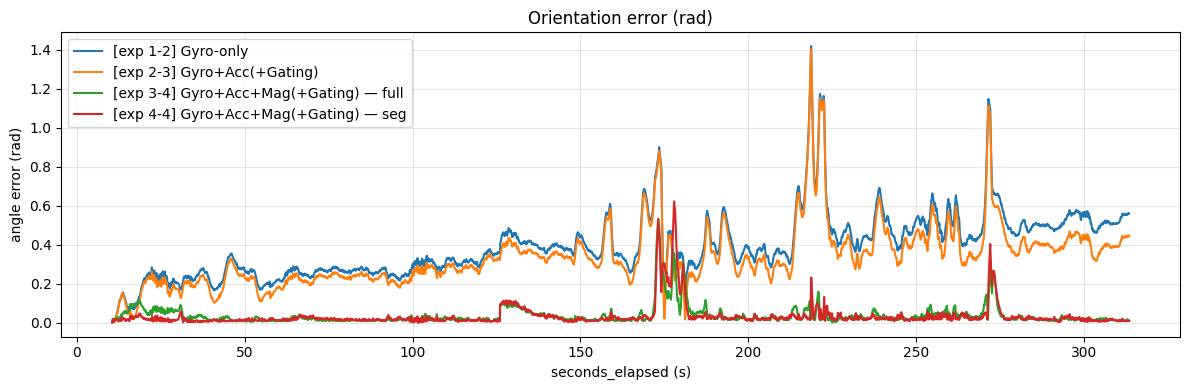

In [15]:
path_err_exp1_2 = out_dir.parent / "exp_1" / "01_exp1-2_angle_err.csv"
best_exp2 = read_best_from_log(out_dir.parent / "exp_2" / "02_exp2_log.txt", 2)
path_err_best_exp2 = out_dir.parent / "exp_2" / f"02_exp{best_exp2}_angle_err.csv"
best_exp3 = read_best_from_log(out_dir.parent / "exp_3" / "03_exp3_log.txt", 3)
path_err_best_exp3 = out_dir.parent / "exp_3" / f"03_exp{best_exp3}_angle_err.csv"
best_exp4 = read_best_from_log(out_dir.parent / "exp_4" / "04_exp4_log.txt", 4)
path_err_best_exp4 = out_dir.parent / "exp_4" / f"04_exp{best_exp4}_angle_err.csv"

plot_err_from_csv([
        ("[exp 1-2] Gyro-only", path_err_exp1_2),
        (f"[exp {best_exp2}] Gyro+Acc(+Gating)", path_err_best_exp2),
        (f"[exp {best_exp3}] Gyro+Acc+Mag(+Gating) — full", path_err_best_exp3),
        (f"[exp {best_exp4}] Gyro+Acc+Mag(+Gating) — seg", path_err_best_exp4)],
                  path_plot)

In [16]:
with Tee(path_log):
        print("[Gravity]")
        g_est_sign_fixed, g_rmse_norm = evaluate_estimated_vec3_autosign(g_est, g_ref_interp)
        save_estimated_vec3_csv(path_est_grav, t_new, g_est_sign_fixed)
        err_grav = calc_vec3_direction_angle_err(g_est_sign_fixed, g_ref_interp)
        print("")
        print_err_status("Gravity est/ref", err_grav)
        print("")

        print("\n[Linear accel]")
        a_lin_est_sign_fixed, a_lin_rmse_norm = evaluate_estimated_vec3_autosign(a_est, a_lin_ref_interp)
        save_estimated_vec3_csv(path_est_acc, t_new, a_lin_est_sign_fixed)
        err_acc_lin = calc_vec3_direction_angle_err(a_lin_est_sign_fixed, a_lin_ref_interp)
        print("")
        print_err_status("Linear accel est/ref", err_acc_lin)
        print("")

        print("\n[Consistency ratio]")
        print("rmse_norm of (a_lin_est / g_est): ", a_lin_rmse_norm / max(g_rmse_norm, EPS))



[START] 2026-03-24 23:30:41.588

[Gravity]
RMSE norm: 0.17186439968691072

Gravity est/ref angle error in rad — min/max/mean/p90
0.0001940564580462738 0.0955435852519144 0.014845698265978232 0.020237530803624882

Gravity est/ref angle error in deg — min/max/mean/p90
0.011118616033309013 5.474244194483072 0.8505958545652373 1.159525102813703


[Linear accel]
RMSE norm: 0.7310720809634389

Linear accel est/ref angle error in rad — min/max/mean/p90
0.00021757833597491768 3.040019383571576 0.13954152389176744 0.315040627008148

Linear accel est/ref angle error in deg — min/max/mean/p90
0.01246632036484223 174.18028031661345 7.995140385822216 18.050498302722055


[Consistency ratio]
rmse_norm of (a_lin_est / g_est):  4.253772638750372

[END] 2026-03-24 23:30:41.961


